# Task 4 — Деревья решений и случайные леса

## Part 2 — Регрессия (California Housing dataset)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 100

## 1. Загрузка и обзор данных

In [24]:
housing = fetch_california_housing()
df_h = pd.DataFrame(housing.data, columns=housing.feature_names)
df_h['MedHouseVal'] = housing.target

print(f'Размер: {df_h.shape}')
print(f'Target: медианная стоимость жилья (в $100,000)')
df_h.head()

Размер: (20640, 9)
Target: медианная стоимость жилья (в $100,000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [25]:
df_h.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [26]:
df_h.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. EDA — регрессия

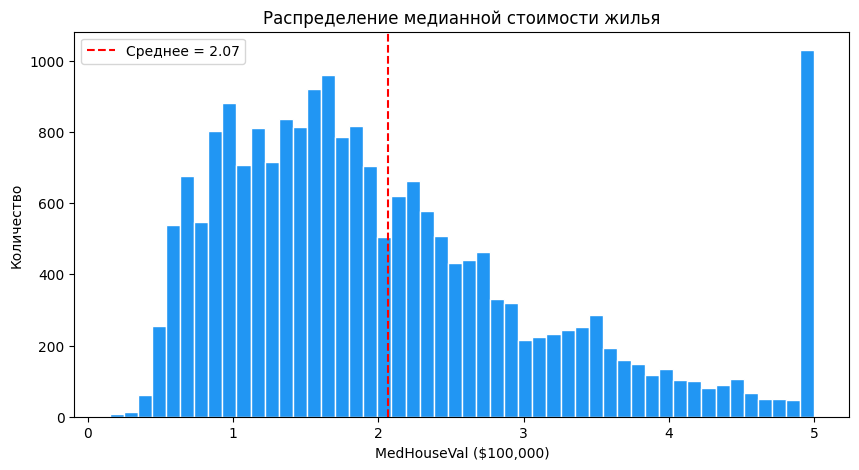

Статистика target:
  Среднее: 2.0686
  Медиана: 1.7970
  Мин: 0.1500
  Макс: 5.0000


In [27]:
# Распределение target
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_h['MedHouseVal'], bins=50, color='#2196F3', edgecolor='white')
ax.set_title('Распределение медианной стоимости жилья')
ax.set_xlabel('MedHouseVal ($100,000)')
ax.set_ylabel('Количество')
ax.axvline(x=df_h['MedHouseVal'].mean(), color='red', linestyle='--',
           label=f'Среднее = {df_h["MedHouseVal"].mean():.2f}')
ax.legend()
plt.show()

print(f'Статистика target:')
print(f'  Среднее: {df_h["MedHouseVal"].mean():.4f}')
print(f'  Медиана: {df_h["MedHouseVal"].median():.4f}')
print(f'  Мин: {df_h["MedHouseVal"].min():.4f}')
print(f'  Макс: {df_h["MedHouseVal"].max():.4f}')

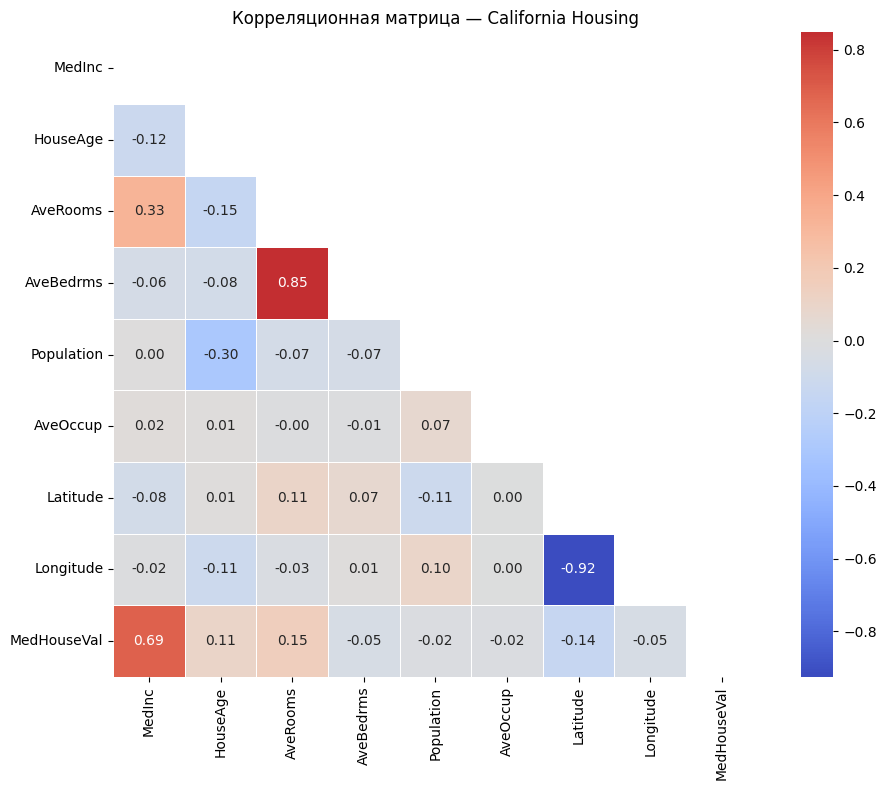

Корреляция с MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160


In [28]:
# Корреляционная матрица
fig, ax = plt.subplots(figsize=(10, 8))
corr_h = df_h.corr()
mask_h = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, mask=mask_h, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Корреляционная матрица — California Housing')
plt.tight_layout()
plt.show()

print('Корреляция с MedHouseVal:')
print(corr_h['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False).to_string())

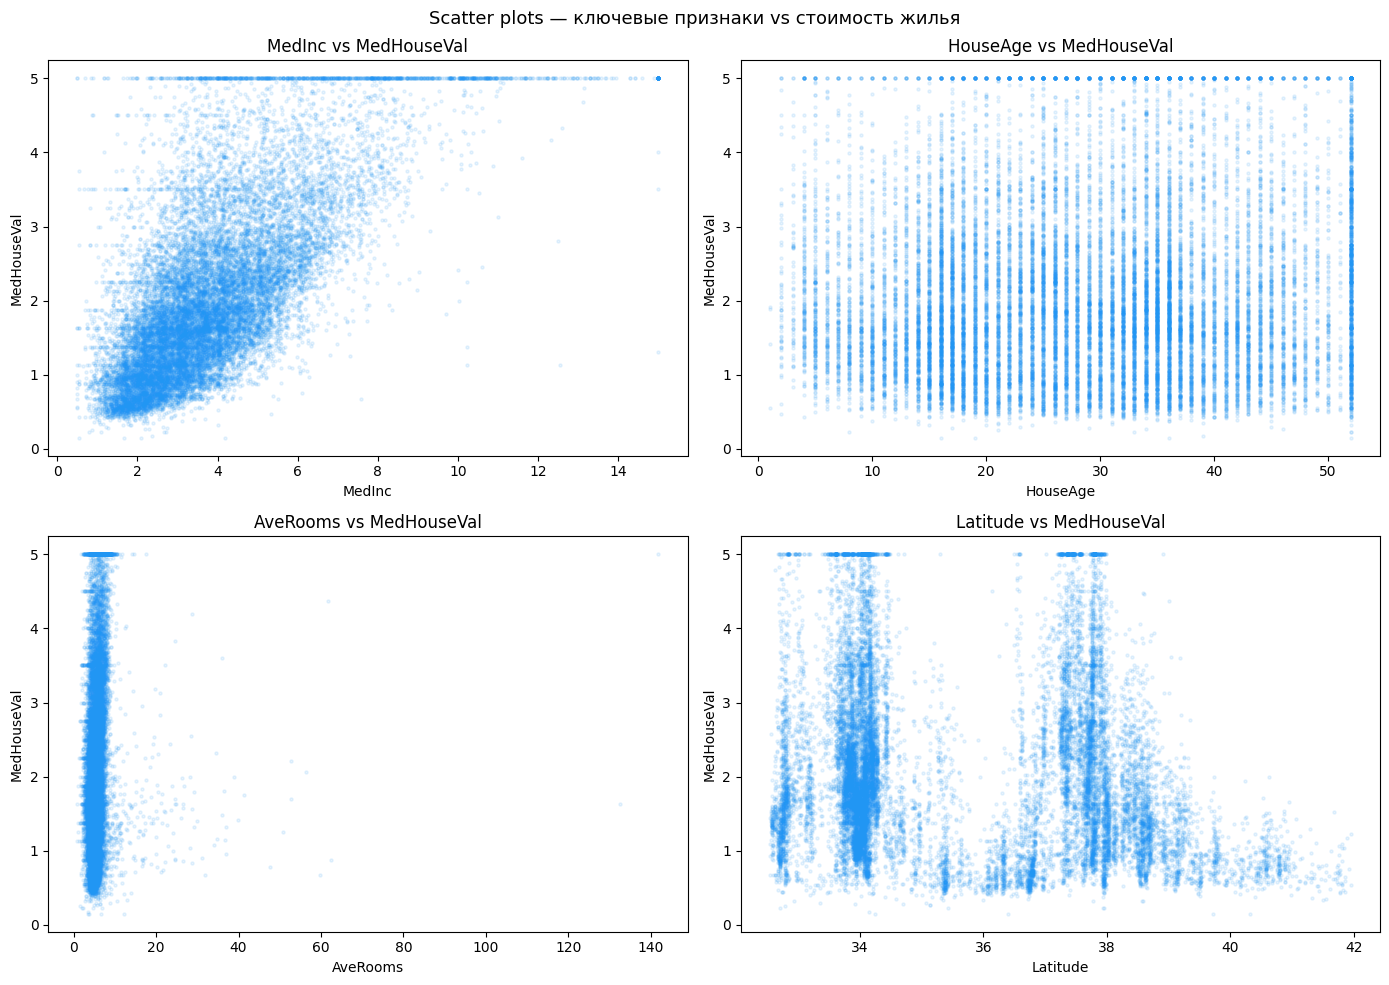

In [29]:
# Scatter plots ключевых признаков vs target
key_features_h = ['MedInc', 'HouseAge', 'AveRooms', 'Latitude']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(key_features_h):
    ax = axes[i // 2, i % 2]
    ax.scatter(df_h[feature], df_h['MedHouseVal'], alpha=0.1, s=5, color='#2196F3')
    ax.set_xlabel(feature)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feature} vs MedHouseVal')
plt.suptitle('Scatter plots — ключевые признаки vs стоимость жилья', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Предобработка — регрессия

In [30]:
# Проверка пропусков
print(f'Пропуски: {df_h.isnull().sum().sum()}')

# Разделение
X_h = df_h.drop('MedHouseVal', axis=1)
y_h = df_h['MedHouseVal']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

print(f'Train: {X_train_h.shape[0]} записей')
print(f'Test:  {X_test_h.shape[0]} записей')

Пропуски: 0
Train: 16512 записей
Test:  4128 записей


## 4. Decision Tree — регрессия

Лучшая глубина (DT Regressor): 9 (CV R² = 0.6835)


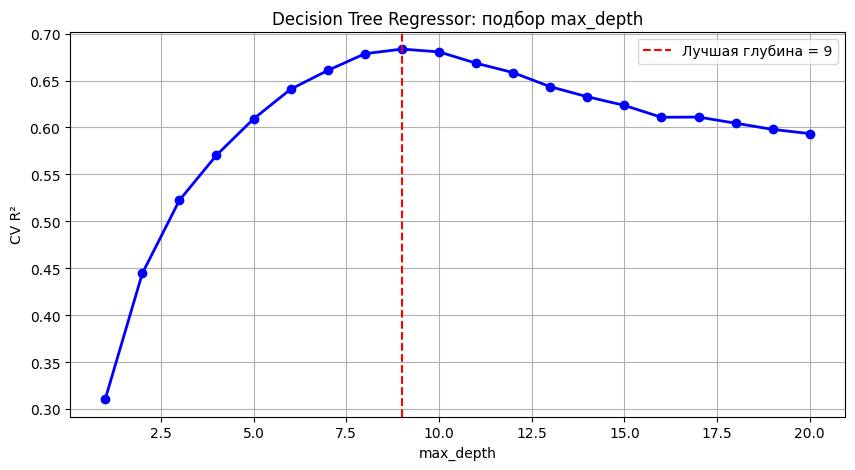

In [31]:
# Подбор max_depth через кросс-валидацию
depths_reg = range(1, 21)
cv_scores_dt_reg = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for depth in depths_reg:
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    scores = cross_val_score(dt_reg, X_train_h, y_train_h, cv=kf, scoring='r2')
    cv_scores_dt_reg.append(scores.mean())

best_depth_dt_reg = list(depths_reg)[np.argmax(cv_scores_dt_reg)]
print(f'Лучшая глубина (DT Regressor): {best_depth_dt_reg} (CV R² = {max(cv_scores_dt_reg):.4f})')

# График
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths_reg, cv_scores_dt_reg, 'bo-', linewidth=2, markersize=6)
ax.axvline(x=best_depth_dt_reg, color='red', linestyle='--', label=f'Лучшая глубина = {best_depth_dt_reg}')
ax.set_xlabel('max_depth')
ax.set_ylabel('CV R²')
ax.set_title('Decision Tree Regressor: подбор max_depth')
ax.legend()
ax.grid(True)
plt.show()

In [32]:
# Финальная модель Decision Tree Regressor
dt_reg_final = DecisionTreeRegressor(max_depth=best_depth_dt_reg, random_state=42)
dt_reg_final.fit(X_train_h, y_train_h)
y_pred_dt_reg = dt_reg_final.predict(X_test_h)

mae_dt = mean_absolute_error(y_test_h, y_pred_dt_reg)
mse_dt = mean_squared_error(y_test_h, y_pred_dt_reg)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test_h, y_pred_dt_reg)

print(f'Decision Tree Regressor (max_depth={best_depth_dt_reg}):')
print(f'  MAE:  {mae_dt:.4f}')
print(f'  MSE:  {mse_dt:.4f}')
print(f'  RMSE: {rmse_dt:.4f}')
print(f'  R²:   {r2_dt:.4f}')

Decision Tree Regressor (max_depth=9):
  MAE:  0.4357
  MSE:  0.4151
  RMSE: 0.6443
  R²:   0.6833


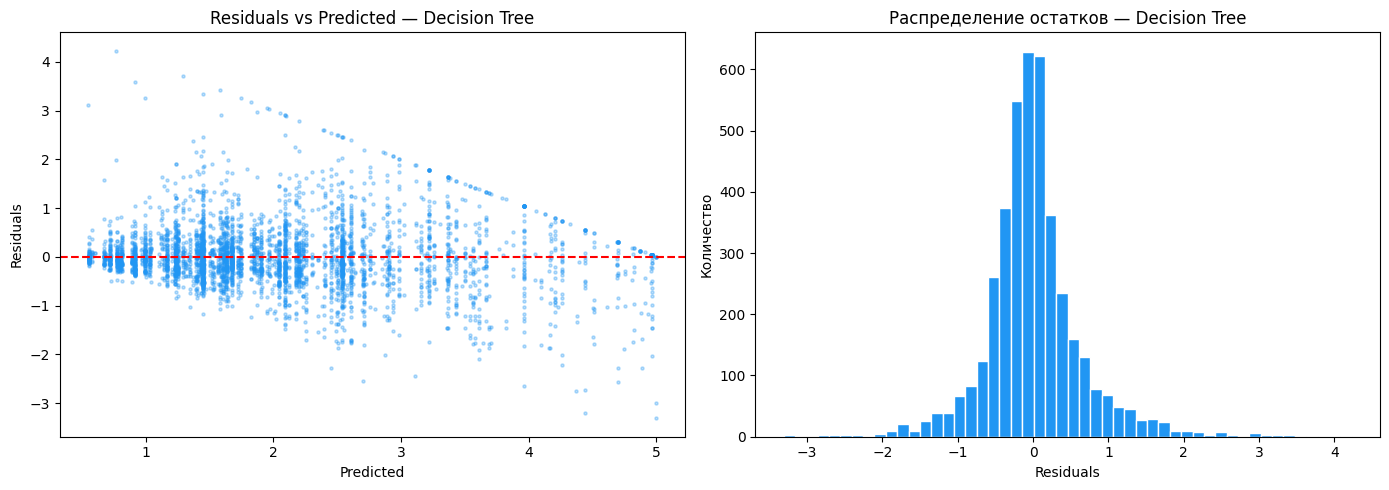

In [33]:
# Residuals — Decision Tree Regressor
residuals_dt = y_test_h - y_pred_dt_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_dt_reg, residuals_dt, alpha=0.3, s=5, color='#2196F3')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted — Decision Tree')

axes[1].hist(residuals_dt, bins=50, color='#2196F3', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение остатков — Decision Tree')

plt.tight_layout()
plt.show()

## 5. Random Forest — регрессия

In [34]:
# Подбор n_estimators
n_est_reg_list = [50, 100, 200, 300]
cv_scores_n_est_reg = []

for n_est in n_est_reg_list:
    rf_reg = RandomForestRegressor(n_estimators=n_est, random_state=42)
    scores = cross_val_score(rf_reg, X_train_h, y_train_h, cv=kf, scoring='r2')
    cv_scores_n_est_reg.append(scores.mean())
    print(f'n_estimators={n_est}: CV R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

best_n_est_reg = n_est_reg_list[np.argmax(cv_scores_n_est_reg)]
print(f'\nЛучшее n_estimators: {best_n_est_reg}')

n_estimators=50: CV R² = 0.8024 (+/- 0.0064)


n_estimators=100: CV R² = 0.8045 (+/- 0.0061)


n_estimators=200: CV R² = 0.8056 (+/- 0.0065)


n_estimators=300: CV R² = 0.8055 (+/- 0.0063)

Лучшее n_estimators: 200


In [35]:
# Подбор max_depth для Random Forest Regressor
depths_rf_reg = list(range(5, 21)) + [None]
cv_scores_depth_rf_reg = []

for depth in depths_rf_reg:
    rf_reg = RandomForestRegressor(n_estimators=best_n_est_reg, max_depth=depth, random_state=42)
    scores = cross_val_score(rf_reg, X_train_h, y_train_h, cv=kf, scoring='r2')
    cv_scores_depth_rf_reg.append(scores.mean())
    label = depth if depth is not None else 'None'
    print(f'max_depth={label}: CV R² = {scores.mean():.4f}')

best_depth_rf_reg_idx = np.argmax(cv_scores_depth_rf_reg)
best_depth_rf_reg = depths_rf_reg[best_depth_rf_reg_idx]
print(f'\nЛучшая глубина RF Regressor: {best_depth_rf_reg}')

max_depth=5: CV R² = 0.6655


max_depth=6: CV R² = 0.7017


max_depth=7: CV R² = 0.7300


max_depth=8: CV R² = 0.7532


max_depth=9: CV R² = 0.7698


...

max_depth=17: CV R² = 0.8049


max_depth=18: CV R² = 0.8052


max_depth=19: CV R² = 0.8053


max_depth=20: CV R² = 0.8052


max_depth=None: CV R² = 0.8056

Лучшая глубина RF Regressor: None


In [36]:
# Финальная модель Random Forest Regressor
rf_reg_final = RandomForestRegressor(
    n_estimators=best_n_est_reg, max_depth=best_depth_rf_reg, random_state=42
)
rf_reg_final.fit(X_train_h, y_train_h)
y_pred_rf_reg = rf_reg_final.predict(X_test_h)

mae_rf = mean_absolute_error(y_test_h, y_pred_rf_reg)
mse_rf = mean_squared_error(y_test_h, y_pred_rf_reg)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_h, y_pred_rf_reg)

print(f'Random Forest Regressor:')
print(f'  n_estimators: {best_n_est_reg}')
print(f'  max_depth: {best_depth_rf_reg}')
print(f'  MAE:  {mae_rf:.4f}')
print(f'  MSE:  {mse_rf:.4f}')
print(f'  RMSE: {rmse_rf:.4f}')
print(f'  R²:   {r2_rf:.4f}')

Random Forest Regressor:
  n_estimators: 200
  max_depth: None
  MAE:  0.3268
  MSE:  0.2540
  RMSE: 0.5040
  R²:   0.8062


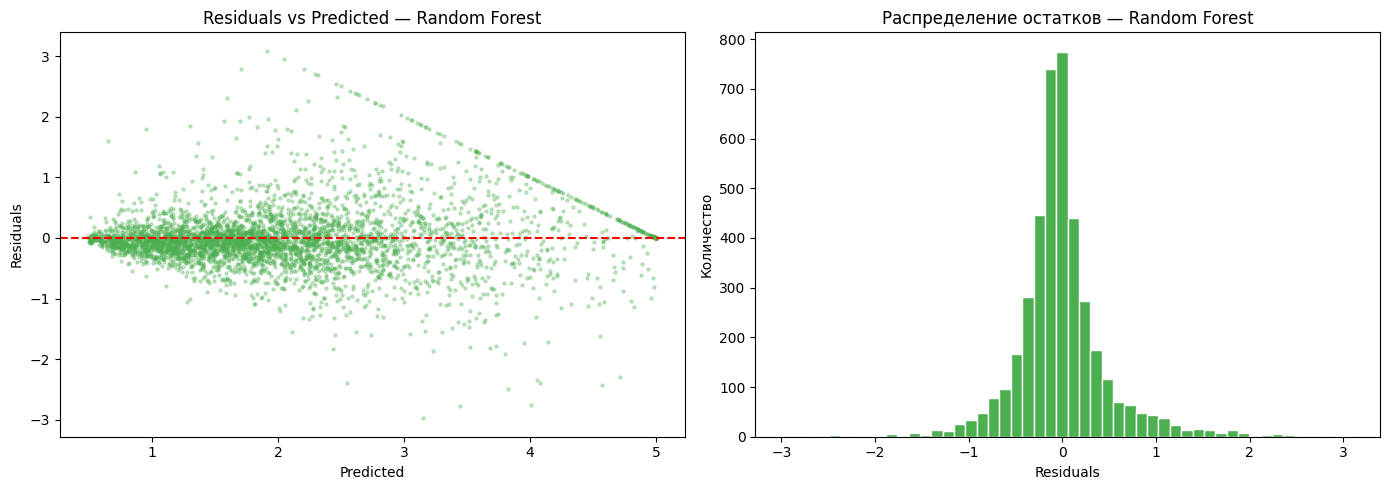

In [37]:
# Residuals — Random Forest Regressor
residuals_rf = y_test_h - y_pred_rf_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_rf_reg, residuals_rf, alpha=0.3, s=5, color='#4CAF50')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted — Random Forest')

axes[1].hist(residuals_rf, bins=50, color='#4CAF50', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение остатков — Random Forest')

plt.tight_layout()
plt.show()

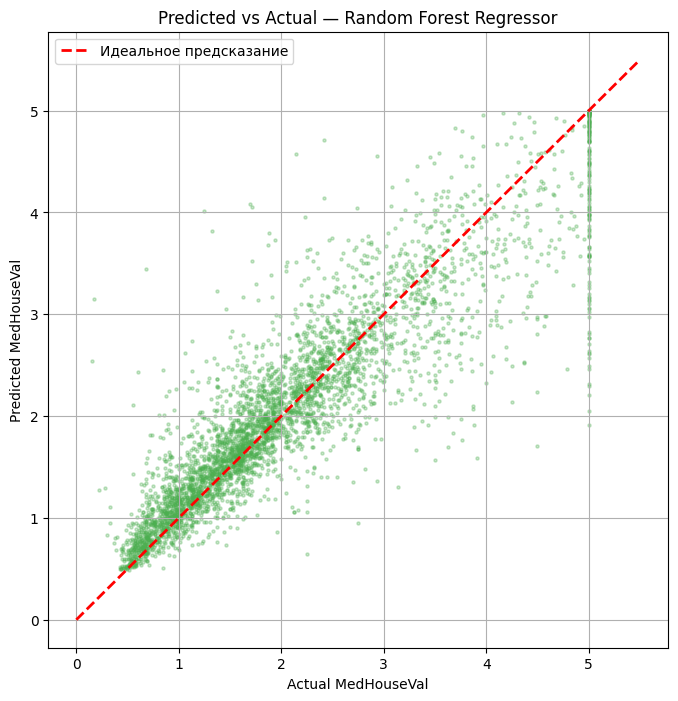

In [38]:
# Predicted vs Actual — Random Forest Regressor
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_h, y_pred_rf_reg, alpha=0.3, s=5, color='#4CAF50')
ax.plot([0, 5.5], [0, 5.5], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Actual MedHouseVal')
ax.set_ylabel('Predicted MedHouseVal')
ax.set_title('Predicted vs Actual — Random Forest Regressor')
ax.legend()
ax.grid(True)
plt.show()

## 6. Feature Importance — регрессия

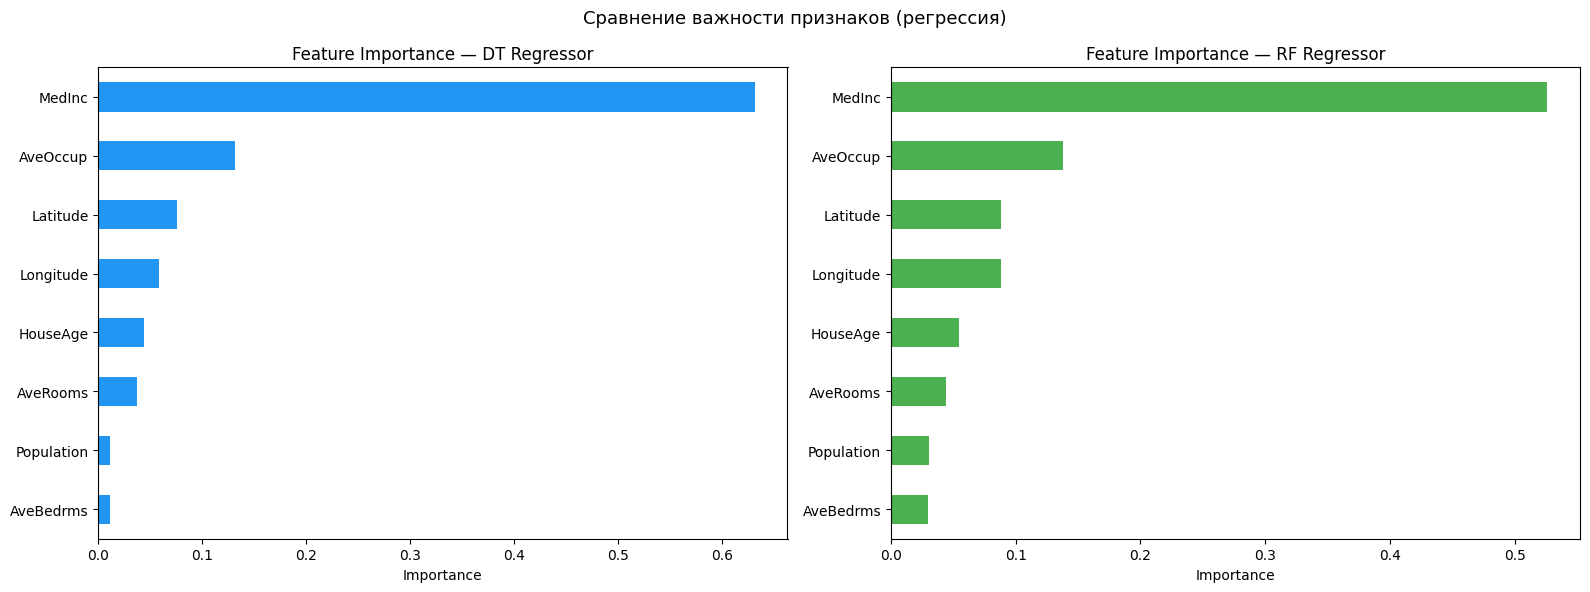

Самый значимый признак (DT Regressor): MedInc (0.6316)
Самый значимый признак (RF Regressor): MedInc (0.5259)


In [39]:
# Feature importance для обеих моделей регрессии
fi_dt_reg = pd.Series(dt_reg_final.feature_importances_, index=housing.feature_names).sort_values(ascending=True)
fi_rf_reg = pd.Series(rf_reg_final.feature_importances_, index=housing.feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_dt_reg.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Feature Importance — DT Regressor')
axes[0].set_xlabel('Importance')

fi_rf_reg.plot(kind='barh', ax=axes[1], color='#4CAF50')
axes[1].set_title('Feature Importance — RF Regressor')
axes[1].set_xlabel('Importance')

plt.suptitle('Сравнение важности признаков (регрессия)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Самый значимый признак (DT Regressor): {fi_dt_reg.idxmax()} ({fi_dt_reg.max():.4f})')
print(f'Самый значимый признак (RF Regressor): {fi_rf_reg.idxmax()} ({fi_rf_reg.max():.4f})')

## Итоги — Регрессия

- **Random Forest Regressor** значительно превосходит одиночное дерево по всем метрикам (MAE, MSE, RMSE, R²).
- **MedInc** (медианный доход) — самый значимый признак для предсказания стоимости жилья.
- Анализ остатков показывает, что модель хуже предсказывает дорогое жильё (ограничение target на уровне 5.0).

### Общий вывод
Ансамблевые методы (Random Forest) превосходят одиночные деревья решений. Деревья хорошо улавливают нелинейные зависимости и взаимодействия между признаками.